### Off-Policy Hyperparametertuning of the DLA Policy

Parameters to be tuned:
- Forecast horizon of the lookahead model - H

In [8]:
import pandas as pd, numpy as np, plotly.express as px, plotly.graph_objects as go

In [1]:
from Models.EnergyStorageModel import EnergyStorageModel as ESM

#### Load Data

In [61]:
# Load policy train data
policy_train_0 = pd.read_csv("./Data/policy_train.csv")
policy_train_005 = pd.read_csv("./Data/policy_train_all_feat_noise005.csv")
policy_train_01 = pd.read_csv("./Data/policy_train_all_feat_noise01.csv")
policy_train_015 = pd.read_csv("./Data/policy_train_all_feat_noise015.csv")
policy_train_02 = pd.read_csv("./Data/policy_train_all_feat_noise02.csv")
policy_train_025 = pd.read_csv("./Data/policy_train_all_feat_noise025.csv")
policy_train_03 = pd.read_csv("./Data/policy_train_all_feat_noise03.csv")
policy_train_035 = pd.read_csv("./Data/policy_train_all_feat_noise035.csv")

policy_test_0 = pd.read_csv("./Data/policy_test.csv")
policy_test_005 = pd.read_csv("./Data/policy_test_all_feat_noise005.csv")
policy_test_01 = pd.read_csv("./Data/policy_test_all_feat_noise01.csv")
policy_test_015 = pd.read_csv("./Data/policy_test_all_feat_noise015.csv")
policy_test_02 = pd.read_csv("./Data/policy_test_all_feat_noise02.csv")
policy_test_025 = pd.read_csv("./Data/policy_test_all_feat_noise025.csv")
policy_test_03 = pd.read_csv("./Data/policy_test_all_feat_noise03.csv")
policy_test_035 = pd.read_csv("./Data/policy_test_all_feat_noise035.csv")

In [62]:
def reshape_dataframe(df):
    array = df.to_numpy()  
    num_cols = array.shape[1]
    new_length = (array.shape[0] // 24) * 24  
    array = array[:new_length, :]  
    reshaped_array = array.reshape(new_length // 24, 24, num_cols).transpose(2, 0, 1)

    return reshaped_array

In [63]:
reshaped_policy_train_0 = reshape_dataframe(policy_train_0)
reshaped_policy_train_005 = reshape_dataframe(policy_train_005)
reshaped_policy_train_01 = reshape_dataframe(policy_train_01)
reshaped_policy_train_015 = reshape_dataframe(policy_train_015)
reshaped_policy_train_02 = reshape_dataframe(policy_train_02)
reshaped_policy_train_025 = reshape_dataframe(policy_train_025)
reshaped_policy_train_03 = reshape_dataframe(policy_train_03)
reshaped_policy_train_035 = reshape_dataframe(policy_train_035)

reshaped_policy_test_0 = reshape_dataframe(policy_test_0)
reshaped_policy_test_005 = reshape_dataframe(policy_test_005)
reshaped_policy_test_01 = reshape_dataframe(policy_test_01)
reshaped_policy_test_015 = reshape_dataframe(policy_test_015)
reshaped_policy_test_02 = reshape_dataframe(policy_test_02)
reshaped_policy_test_025 = reshape_dataframe(policy_test_025)
reshaped_policy_test_03 = reshape_dataframe(policy_test_03)
reshaped_policy_test_035 = reshape_dataframe(policy_test_035)

### Tuning H only on historical data (train) and testing on historical data (test)

In [101]:
from Models.EnergyStorageModel import EnergyStorageModel as ESM
from Models.Policies.DLA import DeterministicLookahead as DL


initial_state = {"energy_amount": 300, "price": reshaped_policy_train_0[0][0]}
init_args = {"eta": 0.95, "Rmax": 600, "max_load_per_hour": 50}
model_name = "cnf-24"
exog_params = {"hist_price": reshaped_policy_train_0[0][1:]}
T = len(reshaped_policy_train_0[0][1:])
t0 = 0

results = {}
for h in range(1, 5):

    DL_model_train = ESM(
        model_name="cnf-24",
        S0=initial_state,
        init_args=init_args,
        exog_params=exog_params,
        T=T,
        t0=t0,
        seed=0
    )

    policy = DL(
        model=DL_model_train,
        policy_name="DL",
        horizon=h,
        verbose=False
    )

    avg_result = policy.run_policy(n_iterations=3)
    results[h] = avg_result

In [102]:
results_df = pd.DataFrame(results, index=[0]).T.reset_index(drop=True) 
results_df.columns = ["Average Reward"]
results_df["Horizon"] = [1, 2, 3, 4]
results_df
# results_df.to_csv("./Data/DL_results.csv", index=False)

,Average Reward,Horizon
0,13418.807451,1
1,12217.114696,2
2,12382.899894,3
3,12170.326221,4


In [ ]:
results_df

,Average Reward,Horizon
0,12160.725496,1
1,12137.411475,2
2,12357.338013,3
3,12141.454477,4
4,12018.491132,5
5,12055.478861,6


In [66]:
from Models.EnergyStorageModel import EnergyStorageModel as ESM
from Models.Policies.DLA import DeterministicLookahead as DL


initial_state = {"energy_amount": 300, "price": reshaped_policy_test_0[0][0]}
init_args = {"eta": 0.95, "Rmax": 600, "max_load_per_hour": 50}
model_name = "cnf-24"
exog_params = {"hist_price": reshaped_policy_test_0[0][1:]}
T = len(reshaped_policy_test_0[0][1:])
t0 = 0

results = {}
for h in range(1, 5):

    DL_model_train = ESM(
        model_name="cnf-24",
        S0=initial_state,
        init_args=init_args,
        exog_params=exog_params,
        T=T,
        t0=t0,
        seed=0
    )

    policy = DL(
        model=DL_model_train,
        policy_name="DL",
        horizon=h,
        verbose=False
    )

    avg_result = policy.run_policy(n_iterations=3)
    results[h] = avg_result

In [70]:
results_df = pd.DataFrame(results, index=[0]).T.reset_index(drop=True) 
results_df.columns = ["Average Reward"]
results_df["Horizon"] = [1, 2, 3, 4]
results_df.to_csv("./Data/DL_results_test_tuned.csv", index=False)

In [77]:
results_df

,Average Reward,Horizon
0,12473.693711,1
1,12872.681329,2
2,12843.171799,3
3,12812.619419,4


### Tuning H on trainscenarios 

In [2]:
import pandas as pd
import numpy as np


policy_train_files = {
    0.0: "./Data/policy_train.csv",
    0.15: "./Data/policy_train_all_feat_noise015.csv",
    0.25: "./Data/policy_train_all_feat_noise025.csv",
    0.35: "./Data/policy_train_all_feat_noise035.csv"
}

policy_test_files = {
    0.0: "./Data/policy_test.csv",
    0.15: "./Data/policy_test_all_feat_noise015.csv",
    0.25: "./Data/policy_test_all_feat_noise025.csv",
    0.35: "./Data/policy_test_all_feat_noise035.csv"
}

def load_and_reshape(file_path, keep_first_column=False):
    df = pd.read_csv(file_path)
    
    if not keep_first_column:
        df.drop(columns=["0"], inplace=True)
    
    array = df.to_numpy()
    num_cols = array.shape[1]
    new_length = (array.shape[0] // 24) * 24
    array = array[:new_length, :]
    reshaped_array = array.reshape(new_length // 24, 24, num_cols).transpose(2, 0, 1)
    
    return reshaped_array


In [32]:
from joblib import Parallel, delayed
import numpy as np, pandas as pd
from Models.EnergyStorageModel import EnergyStorageModel as ESM
from Models.Policies.DLA import DeterministicLookahead as DL

NUM_SCENARIOS = 10  # Anzahl der Szenarien pro Noise-Level
noise_list = [0.15]

def run_scenario(noise):
    reshaped_policy_train = load_and_reshape(policy_train_files[noise], keep_first_column=False)
    reshaped_policy_test = load_and_reshape(policy_test_files[0.0], keep_first_column=True)
    scenario_test_data = reshaped_policy_test[0]  # Feste Test-Daten für alle Szenarien

    init_args = {"eta": 0.95, "Rmax": 600, "max_load_per_hour": 50}
    t0 = 0

    test_performance = {}
    test_model = ESM(
        model_name="cnf-24",
        S0={"energy_amount": 300, "price": scenario_test_data[0]},
        init_args=init_args,
        exog_params={"hist_price": scenario_test_data[1:]},
        T=len(scenario_test_data[1:]),
        t0=t0,
        seed=0
    )

    for h in range(1, 5):
        dl_test = DL(
            model=test_model,
            policy_name="DL",
            horizon=h,
            verbose=False
        )

        result_test = dl_test.run_policy(n_iterations=1)
        test_performance[h] = result_test

    chosen_train_scenarios = np.random.choice(reshaped_policy_train.shape[0], NUM_SCENARIOS, replace=False)

    all_results = []
    for h in range(1, 5):

        for scenario_idx in chosen_train_scenarios:
            scenario_train_data = reshaped_policy_train[scenario_idx, :, :]
            train_model = ESM(
                    model_name="cnf-24",
                    S0={"energy_amount": 300, "price": scenario_train_data[0]},
                    init_args=init_args,
                    exog_params={"hist_price": scenario_train_data[1:]},
                    T=len(scenario_train_data[1:]),
                    t0=t0,
                    seed=0
                )
            
            policy_train = DL(train_model, "DL", h, verbose=False)
            result_train = policy_train.run_policy(n_iterations=1)

            test_performance_h = test_performance[h]

            # Ergebnisse speichern
            all_results.append({
                "noise": noise,
                "h": h,
                "scenario_idx": scenario_idx,
                "train_performance": result_train,
                "test_performance": test_performance_h  
            })

    return all_results

# **Parallelisierung für alle Noise-Werte**
results = Parallel(n_jobs=-1)(delayed(run_scenario)(noise) for noise in noise_list)

# **Flatten der Listen in ein DataFrame**
results_flat = [entry for sublist in results for entry in sublist]
results_df = pd.DataFrame(results_flat)

# **Normierte Performance berechnen**
global_best_test_performance = results_df["test_performance"].max()
results_df["norm_performance"] = results_df["test_performance"] / global_best_test_performance
results_df.loc[results_df["test_performance"] == 0, "norm_performance"] = np.nan

In [33]:
results_df.to_csv("./Data/DL_results_train_test015.csv", index=False)

In [34]:
results_df

,noise,h,scenario_idx,train_performance,test_performance,norm_performance
0,0.15,1,15,14363.500251,12473.693711,0.968859
1,0.15,1,35,14142.386770,12473.693711,0.968859
2,0.15,1,63,14070.034081,12473.693711,0.968859
3,0.15,1,82,13953.995677,12473.693711,0.968859
4,0.15,1,97,14087.865665,12473.693711,0.968859
5,0.15,1,56,14196.282102,12473.693711,0.968859
6,0.15,1,25,14164.542311,12473.693711,0.968859
7,0.15,1,36,14192.974751,12473.693711,0.968859
8,0.15,1,51,14142.515887,12473.693711,0.968859
9,0.15,1,20,14043.013058,12473.693711,0.968859


In [37]:
results_0 = pd.read_csv("./Data/DL_results_train_test0.csv")
results_015 = pd.read_csv("./Data/DL_results_train_test015.csv")
results_025 = pd.read_csv("./Data/DL_results_train_test025.csv")
results_035 = pd.read_csv("./Data/DL_results_train_test035.csv")

In [74]:
results_0.groupby(["noise", "h"]).mean()

scenario_idx  train_performance  test_performance  norm_performance
noise h                                                                     
0.0   1          32.7       15059.109502      12473.693711          0.966538
      2          32.7       13595.508721      12905.543558          1.000000
      3          32.7       13767.868570      12826.698701          0.993891
      4          32.7       13668.955880      12816.267908          0.993082

In [75]:
results_015.groupby(["noise", "h"]).mean()

scenario_idx  train_performance  test_performance  norm_performance
noise h                                                                     
0.15  1          48.0       14135.711056      12473.693711          0.968859
      2          48.0       12941.507007      12863.144626          0.999109
      3          48.0       12981.189654      12874.616289          1.000000
      4          48.0       12907.315593      12828.680618          0.996432

In [76]:
results_025.groupby(["noise", "h"]).mean()

scenario_idx  train_performance  test_performance  norm_performance
noise h                                                                     
0.25  1          58.4       15290.759691      12473.693711          0.968342
      2          58.4       14065.971766      12881.498846          1.000000
      3          58.4       14141.580373      12869.688884          0.999083
      4          58.4       14063.697868      12823.823991          0.995523

In [39]:
results_df_all = pd.concat([results_0, results_015, results_025, results_035], axis=0)  

In [55]:
results_df_all[["test_performance"]].max()

test_performance    12905.543558
dtype: float64

In [82]:
results_grouped = results_df_all.groupby(["noise", "h"]).agg({"train_performance": "mean", "test_performance": "mean", "norm_performance": "mean"}).reset_index()
results_grouped["norm_performance"] = results_grouped["test_performance"] / results_grouped["test_performance"].max()
results_grouped

,noise,h,train_performance,test_performance,norm_performance
0,0.00,1,15059.109502,12473.693711,0.966538
1,0.00,2,13595.508721,12905.543558,1.000000
2,0.00,3,13767.868570,12826.698701,0.993891
3,0.00,4,13668.955880,12816.267908,0.993082
4,0.15,1,14135.711056,12473.693711,0.966538
5,0.15,2,12941.507007,12863.144626,0.996715
6,0.15,3,12981.189654,12874.616289,0.997604
7,0.15,4,12907.315593,12828.680618,0.994044
8,0.25,1,15290.759691,12473.693711,0.966538
9,0.25,2,14065.971766,12881.498846,0.998137


In [83]:
results_grouped.loc[results_grouped["h"] == 1, "test_performance"] = 12473.693711
results_grouped.loc[results_grouped["h"] == 2, "test_performance"] = 12872.681329
results_grouped.loc[results_grouped["h"] == 3, "test_performance"] = 12843.171799
results_grouped.loc[results_grouped["h"] == 4, "test_performance"] = 12812.619419

In [104]:
results_grouped

,noise,h,train_performance,test_performance,norm_performance
0,0.00,1,15059.109502,12473.693711,0.966538
1,0.00,2,13595.508721,12872.681329,1.000000
2,0.00,3,13767.868570,12843.171799,0.993891
3,0.00,4,13668.955880,12812.619419,0.993082
4,0.15,1,14135.711056,12473.693711,0.966538
5,0.15,2,12941.507007,12872.681329,0.996715
6,0.15,3,12981.189654,12843.171799,0.997604
7,0.15,4,12907.315593,12812.619419,0.994044
8,0.25,1,15290.759691,12473.693711,0.966538
9,0.25,2,14065.971766,12872.681329,0.998137


In [86]:
results_grouped.to_csv("./Data/DL_results_grouped.csv", index=False)

<Axes: xlabel='h'>

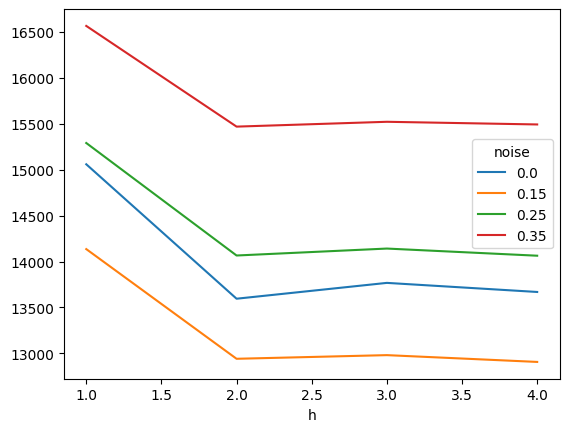

In [105]:
results_grouped.set_index(["noise", "h"])["train_performance"].unstack().T.plot()

<Axes: xlabel='h'>

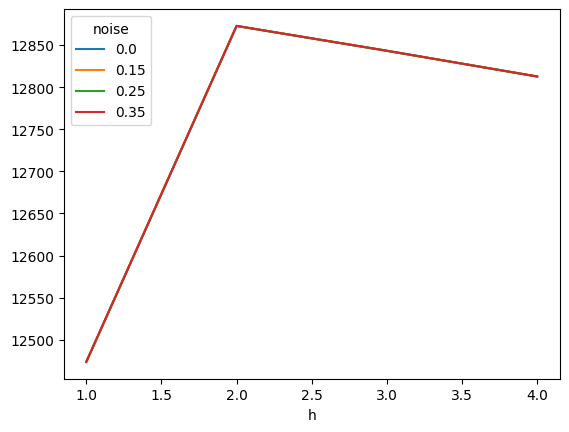

In [111]:
results_grouped.set_index(["noise", "h"])["test_performance"].unstack().T.plot()